Part2

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
data_path = "/content/wdbc.data"
df = pd.read_csv(data_path, header=None)

columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
df.columns = columns

In [3]:
df = df.drop('ID', axis=1)
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0}) #Malignant=1恶性, Benign=0

X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
results = []
for criterion in ['gini', 'entropy']:
    for depth in range(1, 7):
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append((criterion, depth, acc))

In [5]:
results_df = pd.DataFrame(results, columns=['Criterion', 'Depth', 'Accuracy'])
print("Accuracy Results:")
print(results_df.sort_values('Accuracy', ascending=False))

Accuracy Results:
   Criterion  Depth  Accuracy
8    entropy      3  0.964912
3       gini      4  0.947368
4       gini      5  0.947368
2       gini      3  0.947368
11   entropy      6  0.947368
10   entropy      5  0.947368
9    entropy      4  0.947368
5       gini      6  0.938596
1       gini      2  0.929825
7    entropy      2  0.912281
0       gini      1  0.894737
6    entropy      1  0.894737


In [6]:
best_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_criterion = best_row['Criterion']
best_depth = int(best_row['Depth'])
print(f"Best Model → Criterion = {best_criterion}, Depth = {best_depth}")

Best Model → Criterion = entropy, Depth = 3


In [7]:
best_model = DecisionTreeClassifier(criterion=best_criterion, max_depth=best_depth, random_state=42)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

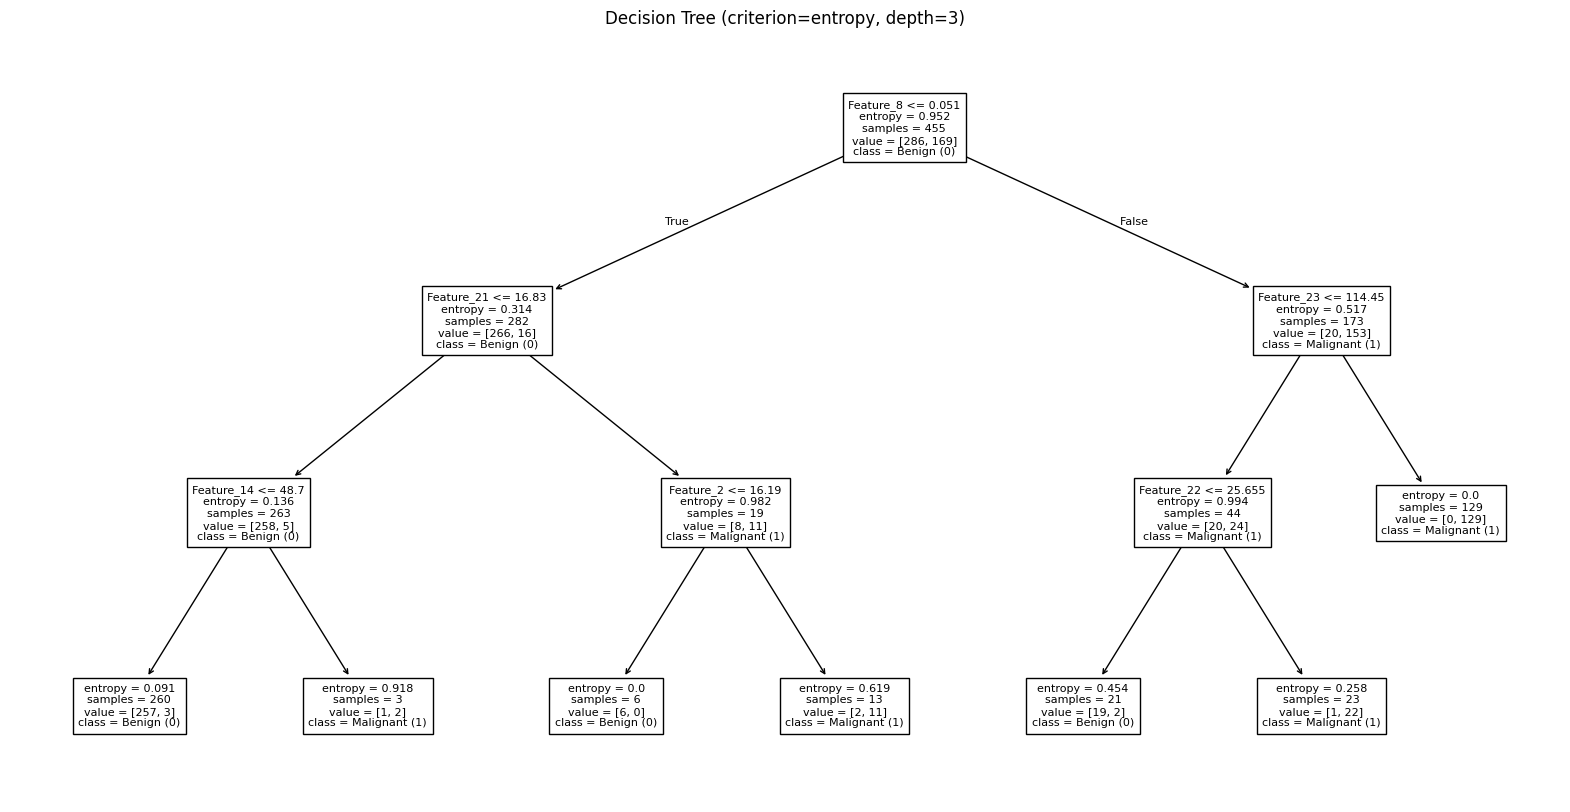

In [11]:
plt.figure(figsize=(20,10))
plot_tree(
  best_model,
  impurity=True,
  feature_names=X.columns,
  class_names=['Benign (0)', 'Malignant (1)'],
  fontsize=8
)
plt.title(f"Decision Tree (criterion={best_criterion}, depth={best_depth})")
plt.show()

Part3

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [13]:
param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6],
    'criterion': ['gini', 'entropy'],
    'n_estimators': [50, 100, 200], #number of trees
    'oob_score': [True],
    'bootstrap': [True],
    'random_state': [42]
}

In [14]:
rf = RandomForestClassifier()
grid_search = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6],
                         'n_estimators': [50, 100, 200], 'oob_score': [True],
                         'random_state': [42]},
             verbose=1)

In [19]:
print("DecisionTreeClassifier parameters:")
print(DecisionTreeClassifier().get_params().keys())

print("\nRandomForestClassifier parameters:")
print(RandomForestClassifier().get_params().keys())

DecisionTreeClassifier parameters:
dict_keys(['ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'random_state', 'splitter'])

RandomForestClassifier parameters:
dict_keys(['bootstrap', 'ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'])


In [15]:
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

Best Parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 6, 'n_estimators': 100, 'oob_score': True, 'random_state': 42}


In [17]:
y_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (Random Forest): {test_acc:.4f}")

print(f"OOB Score: {best_rf.oob_score_:.4f}")

Test Accuracy (Random Forest): 0.9649
OOB Score: 0.9648


In [18]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))


Decision Tree Accuracy: 0.9474
Random Forest Accuracy: 0.9649
Increase: 1.75%


In [21]:
from sklearn.ensemble import AdaBoostClassifier

base_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

ada = AdaBoostClassifier(
  estimator=base_tree,
  n_estimators=100,
  learning_rate=0.1,
  random_state=42
)
ada.fit(X_train, y_train)


y_pred_ada = ada.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)

print(f"AdaBoost Test Accuracy: {ada_acc:.4f}")

print("Model Performance Comparison")
print(f"Decision Tree Accuracy : {dt_acc:.4f}")
print(f"Random Forest Accuracy : {test_acc:.4f}")
print(f"AdaBoost  Accuracy : {ada_acc:.4f}")


AdaBoost Test Accuracy: 0.9561
Model Performance Comparison
Decision Tree Accuracy : 0.9474
Random Forest Accuracy : 0.9649
AdaBoost  Accuracy : 0.9561


Random Forest shares several parameters with Decision Tree (criterion, max_depth, etc.), but introduces additional ensemble parameters such as n_estimators, bootstrap, and oob_score.

Using the same training and testing sets as the Decision Tree experiment,
a Random Forest Classifier's test accuracy reached 96.5%, compared to 94.7% for the single Decision Tree. The out-of-bag score was 0.9648, consistent with test accuracy, confirming good generalization and no overfitting.

The AdaBoost model reached 95.6% test accuracy.

Overall, ensemble methods (Random Forest and Boosting) significantly improved performance over a single tree.

Part4

In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
  n_estimators=100,
  max_depth=5,
  learning_rate=0.1,
  subsample=0.8,
  colsample_bytree=0.8,
  random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

XGBoost Accuracy: 0.9561


XGBoost builds many small decision trees one after another. Each new tree tries to fix the mistakes made by the previous trees.
At the end, all trees are combined to make a strong final prediction.

1.The first tree makes predictions (some are wrong).

2.The second tree learns from those errors and tries to correct them.

3.The third tree again focuses on what’s still wrong.

4.Finally, all trees are added together → final result.

Compare:

AdaBoost focuses on sample weights,

Gradient Boosting focuses on prediction errors,

XGBoost combines both ideas with more efficient and powerful training.

Part1 and bonus questions are written in the pdf.